In [105]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [ ]:
def proj([x,y]):
    return y

In [21]:
def preimage(Y,cover):
    n = len(Y)
    m,_ = cover.shape
    A = np.zeros((n,m))
    
    for i in range(n):
        for j in range(m):
            if np.abs(Y[i]-cover[j,0]) < cover[j,1]:
                A[i,j] = 1
    return A

In [22]:
cover = np.zeros((4,2))
cover[:,0]= np.arange(0,4)
cover[:,1]= (np.random.rand(4)+1)/2
cover

array([[0.        , 0.98451661],
       [1.        , 0.62206623],
       [2.        , 0.73068341],
       [3.        , 0.50777204]])

In [23]:
y = np.random.rand(20)*3
y

array([0.26651657, 2.51833851, 1.21240053, 2.85838767, 0.75553674,
       2.04054243, 0.10946348, 1.54478511, 2.07586359, 0.1193527 ,
       0.96638044, 2.34075901, 2.42102876, 0.38028029, 0.37204445,
       2.28209568, 2.11706887, 1.98117158, 0.10758408, 1.27578856])

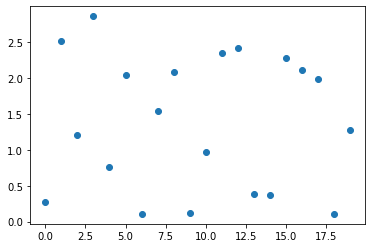

In [24]:
plt.scatter(range(len(y)),y)

In [25]:
my_matrix = preimage(y,cover)

In [26]:
my_matrix

array([[1., 0., 0., 0.],
       [0., 0., 1., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 1., 0.]])

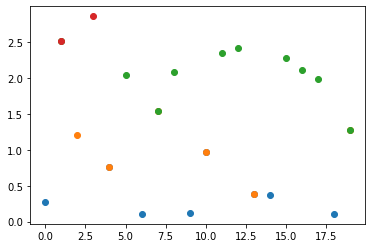

In [33]:
for i in range(len(cover[:,0])):
    cluster = y[my_matrix[:,i]==1]
    cluster_x = np.arange(len(y))[my_matrix[:,i]==1]
    plt.scatter(cluster_x,cluster)

In [84]:
def begin_indexing(A):
    x = np.max(A,axis = 0)
    total_clusters = np.sum(x)
    partial_sums = np.cumsum(x) -x[0]
    return total_clusters.astype(int),partial_sums.astype(int)

In [85]:
a,b, = begin_indexing(my_matrix)

In [86]:
a

4

In [87]:
b

array([0, 1, 2, 3])

In [88]:
new_matrix = my_matrix.copy()

In [89]:
Q= np.random.choice(4,size=(20,4))
Q

array([[3, 1, 2, 2],
       [2, 1, 1, 0],
       [1, 2, 2, 2],
       [3, 3, 2, 2],
       [3, 0, 0, 1],
       [0, 1, 0, 2],
       [1, 1, 2, 3],
       [2, 2, 3, 0],
       [3, 2, 1, 1],
       [1, 0, 0, 2],
       [0, 2, 0, 0],
       [1, 3, 2, 3],
       [3, 0, 1, 3],
       [3, 3, 3, 3],
       [3, 0, 3, 2],
       [2, 2, 0, 0],
       [2, 2, 2, 1],
       [3, 3, 1, 2],
       [2, 2, 0, 2],
       [3, 2, 2, 1]])

In [90]:
new_matrix = new_matrix*Q.astype(int)
new_matrix

array([[3., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 2., 0., 0.],
       [0., 0., 0., 2.],
       [3., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 2., 3., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 2., 0., 0.],
       [0., 0., 2., 0.],
       [0., 0., 1., 0.],
       [3., 3., 0., 0.],
       [3., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 2., 0.],
       [0., 0., 1., 0.],
       [2., 0., 0., 0.],
       [0., 2., 2., 0.]])

In [91]:
a,b, = begin_indexing(new_matrix)

In [92]:
a.astype(int)

11

In [93]:
b

array([0, 3, 6, 8])

In [94]:
def create_empty_adjacency(total_clusters):
    return np.zeros((total_clusters,total_clusters))

In [95]:
A = create_empty_adjacency(a)
A

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [96]:
A.shape

(11, 11)

In [98]:
def index_tracker(preim_cluster,partial_sums):
    
    return partial_sums[preim_cluster[0]] + preim_cluster[1] - 1

In [101]:
index_tracker((1,new_matrix[7,1]), b)

4.0

In [102]:
vect = np.array([0,1,2,0,3,4])
np.nonzero(vect)

(array([1, 2, 4, 5]),)

In [103]:
Q.shape

(20, 4)

In [104]:
for i in range(len(X)):
    
    xi = X[i,:]
    
    where_preimage = np.nonzero(xi)[0] # returns indices of columns with nonzero entries in row i
    col_preim = [(j,A[i,j]) for j in where_preimage]
    xi_clusters = [index_tracker(entry, partial_sums) for entry in col_preim]
    cluster_pairs = list(product(xi_clusters,xi_clusters))
    

20

In [107]:
list(product(vect,vect))

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 0),
 (0, 3),
 (0, 4),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 0),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 0),
 (2, 3),
 (2, 4),
 (0, 0),
 (0, 1),
 (0, 2),
 (0, 0),
 (0, 3),
 (0, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 0),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 0),
 (4, 3),
 (4, 4)]

In [111]:
vect = np.array([0,1,2,0,3,4])
tu = np.nonzero(vect)[0]

In [112]:
tu

array([1, 2, 4, 5])

In [126]:
foo = np.asarray([(2,i) for i in tu])
foo

array([[2, 1],
       [2, 2],
       [2, 4],
       [2, 5]])

In [127]:
index_tracker(foo,b)

array([7, 4])

In [128]:
[index_tracker(entry, b) for entry in foo]

[6, 7, 9, 10]